## 1.Install library
#### Install numpy, vnstock, pandas_ta, ta_lib, mplfinance

In [ ]:
!pip install vnstock

In [ ]:
pip install --upgrade pandas_ta

In [ ]:
!pip install git+https://github.com/thinh-vu/vnstock.git

In [ ]:
pip install --upgrade mathplotib.pyplot

In [ ]:
pip install numpy==1.23.5

In [ ]:
pip install statsmodels scikit-learn plotly

In [33]:
pip install --upgrade nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 2. Data

In [ ]:
from vnstock import *

In [3]:
from vnstock import Listing
listing = Listing()
listing.all_symbols()

,symbol,organ_name
0,YTC,Công ty Cổ phần Xuất nhập khẩu Y tế Thành phố ...
1,YEG,Công ty Cổ phần Tập đoàn Yeah1
2,YBM,Công ty Cổ phần Khoáng sản Công nghiệp Yên Bái
3,YBC,Công ty Cổ phần Xi măng và Khoáng sản Yên Bái
4,XPH,Công ty Cổ phần Xà phòng Hà Nội
...,...,...
1704,AAS,Công ty Cổ phần Chứng khoán SmartInvest
1705,AAM,Công ty Cổ Phần Thủy Sản MeKong
1706,AAH,Công ty Cổ phần Hợp Nhất
1707,AAA,Công ty Cổ phần Nhựa An Phát Xanh


In [4]:
from vnstock import Vnstock
company = Vnstock().stock(symbol='VIC', source='VCI').company
company.overview()

DataFrame.applymap has been deprecated. Use DataFrame.map instead.


,symbol,id,issue_share,history,company_profile,icb_name3,icb_name2,icb_name4,financial_ratio_issue_share,charter_capital
0,VIC,76055,3823661561,- Ngày 03/05/2002: Tiền thân là Công ty Cổ ph...,Tập đoàn Vingroup - Công ty Cổ phần (VIC) có ...,Bất động sản,Bất động sản,Bất động sản,3878583300,38785833060000


In [60]:
import pandas as pd
import pandas_ta as ta
from vnstock import Vnstock

stock = Vnstock().stock(symbol='VIC', source='VCI')
df = stock.quote.history(start='2024-01-01', end='2025-03-29', interval='1D')

df['Previous_Close'] = df['close'].shift(1) 
df['Close_shifted'] = df['close'].shift(1)
df['Open_shifted'] = df['open'].shift(1)
df['High_shifted'] = df['high'].shift(1)
df['Low_shifted'] = df['low'].shift(1)
df = pd.DataFrame(df)
df.dropna(inplace=True)
print(df)

          time   open   high   low  close    volume  Previous_Close  \
1   2024-01-03  43.50  44.15  43.5  44.15   2277071           44.00   
2   2024-01-04  44.15  44.40  43.8  44.15   2340552           44.15   
3   2024-01-05  44.15  44.20  43.9  44.10   1483990           44.15   
4   2024-01-08  44.45  44.75  44.1  44.35   2537739           44.10   
5   2024-01-09  44.30  44.40  43.9  43.90   1606614           44.35   
..         ...    ...    ...   ...    ...       ...             ...   
302 2025-03-24  53.00  56.70  52.7  56.70  11901000           53.00   
303 2025-03-25  57.70  59.20  56.6  56.90   7932000           56.70   
304 2025-03-26  57.80  58.00  55.7  57.00   6487700           56.90   
305 2025-03-27  57.50  58.70  56.6  57.10   4569200           57.00   
306 2025-03-28  57.00  58.30  56.9  58.00   5542600           57.10   

     Close_shifted  Open_shifted  High_shifted  Low_shifted  
1            44.00         44.95         44.95         44.0  
2            44.15     

## 3. Indicator

In [ ]:
df['SMA_50'] = ta.sma(df['Close_shifted'], length=50)

df['EMA_50'] = ta.ema(df['Close_shifted'], length=50)

df['RSI'] = ta.rsi(df['Close_shifted'], length=14)

macd = ta.macd(df['Close_shifted'], fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']        # MACD line
df['Signal_Line'] = macd['MACDs_12_26_9'] # Signal line

bollinger = ta.bbands(df['Close_shifted'], length=20, std=2)
df['BB_Upper'] = bollinger['BBU_20_2.0']  # Upper Bollinger Band
df['BB_Middle'] = bollinger['BBM_20_2.0'] # Middle Band (20-period SMA)
df['BB_Lower'] = bollinger['BBL_20_2.0']  # Lower Bollinger Band

stoch = ta.stoch(df['High_shifted'], df['Low_shifted'], df['Close_shifted'], k=14, d=3)
df['%K'] = stoch['STOCHk_14_3_3'] # %K line (main line)
df['%D'] = stoch['STOCHd_14_3_3'] # %D line (3-period moving average of %K)

df['ATR'] = ta.atr(df['High_shifted'], df['Low_shifted'], df['Close_shifted'], length=14)

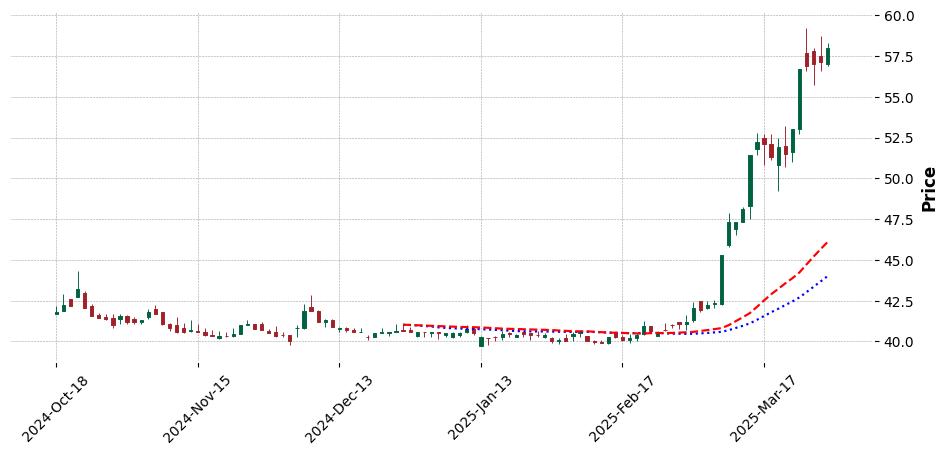

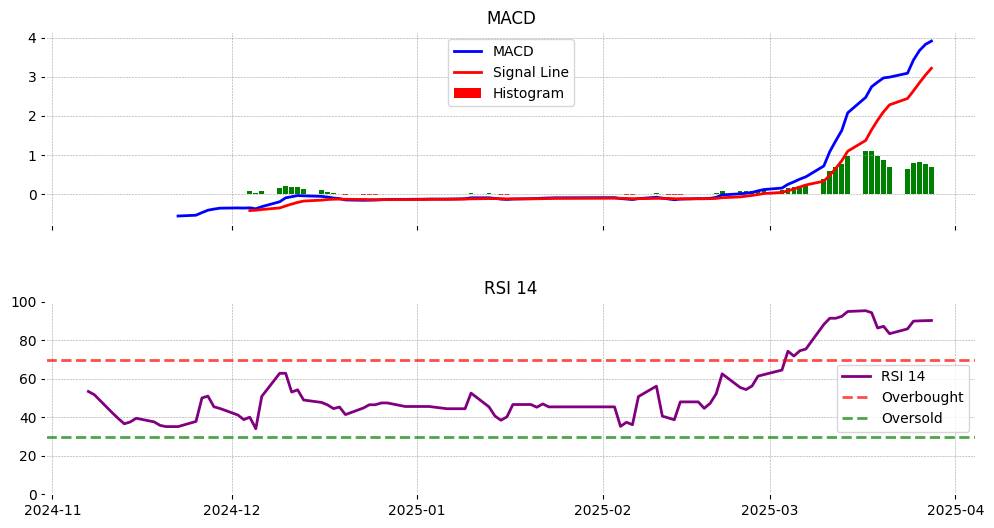

In [66]:
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import mplfinance as mpf
import matplotlib.dates as mdates
import os

# Kiểm tra nếu DataFrame chưa có index dạng thời gian
if not isinstance(df.index, pd.DatetimeIndex):
    df["time"] = pd.to_datetime(df["time"])
    df.set_index("time", inplace=True)
    df.sort_index(inplace=True)

# Xóa dữ liệu bị thiếu để tránh lỗi NaN
df.dropna(inplace=True)

# Tính toán các chỉ báo kỹ thuật
df['SMA_50'] = ta.sma(df['Close_shifted'], length=50)
df['EMA_50'] = ta.ema(df['Close_shifted'], length=50)
df['RSI'] = ta.rsi(df['Close_shifted'], length=14)

macd = ta.macd(df['Close_shifted'], fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']
df['Signal_Line'] = macd['MACDs_12_26_9']
df['MACD_Hist'] = macd['MACDh_12_26_9']

# 🎯 Vẽ biểu đồ Nến trước, rồi mới vẽ MACD & RSI
mpf_fig, mpf_axes = mpf.plot(
    df,
    type='candle',
    style='charles',
    volume=False,
    addplot=[
        mpf.make_addplot(df["SMA_50"], color='blue', linestyle='dotted'),
        mpf.make_addplot(df["EMA_50"], color='red', linestyle='dashed')
    ],
    returnfig=True,  # Trả về Figure để tùy chỉnh tiếp
    figsize=(12, 5)
)

# 🎯 Vẽ thêm MACD và RSI trên plt.subplots()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
plt.subplots_adjust(hspace=0.4)

# 🎯 Biểu đồ MACD
axes[0].plot(df.index, df["MACD"], label="MACD", color="blue")
axes[0].plot(df.index, df["Signal_Line"], label="Signal Line", color="red")
axes[0].bar(df.index, df["MACD_Hist"], label="Histogram", color=['green' if val >= 0 else 'red' for val in df["MACD_Hist"]])
axes[0].legend()
axes[0].set_title("MACD", fontsize=12)

# 🎯 Biểu đồ RSI
axes[1].plot(df.index, df["RSI"], label="RSI 14", color="purple")
axes[1].axhline(70, linestyle="--", color="red", alpha=0.7, label="Overbought")
axes[1].axhline(30, linestyle="--", color="green", alpha=0.7, label="Oversold")
axes[1].set_ylim(0, 100)  # Giới hạn RSI từ 0 - 100
axes[1].legend()
axes[1].set_title("RSI 14", fontsize=12)

for ax in axes:
    ax.tick_params(axis='both', labelsize=10)

# 🎯 Lưu và mở ảnh
plt.savefig("stock_analysis.png", dpi=300, bbox_inches="tight")
os.startfile("stock_analysis.png")

plt.show()


## 4. Using indicator to analyst

### 4.1.Modeling

In [67]:
window_size = 30  

indicators = ['SMA_50', 'EMA_50', 'RSI', 'MACD', 'Signal_Line', 'Close_shifted', 'Previous_Close']

results = {indicator: {'predictions': [], 'actual': [], 'daily_mae': []} for indicator in indicators}

In [68]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

In [69]:
for i in range(window_size, len(df) - 1):
    train_df = df.iloc[i - window_size:i]  
    test_index = i + 1  
    actual_close_price = df['close'].iloc[test_index] 

    for indicator in indicators[:-1]:  
        X_train = train_df[[indicator, 'Previous_Close']]
        y_train = train_df['close']

        # Thêm cột constant vào X_train
        X_train = sm.add_constant(X_train)
        # Kiểm tra NaN/Inf
        X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
        y_train = y_train.loc[X_train.index]  # Cập nhật y_train tương ứng

        # Đảm bảo X_train không rỗng
        if X_train.empty:
            continue

        X_train = sm.add_constant(X_train)
        X_train = X_train.loc[:, X_train.columns != 'const']
        model = sm.OLS(y_train, X_train).fit()
        X_test = pd.DataFrame([[df[indicator].iloc[test_index], df['Previous_Close'].iloc[test_index]]], 
                      columns=[indicator, 'Previous_Close'])

        X_test = sm.add_constant(X_test)  # Thêm hệ số intercept nếu chưa có
 
        # Dự đoán giá đóng cửa
        prediction = model.predict(X_test)[0]
        results[indicator]['predictions'].append(prediction)
        results[indicator]['actual'].append(actual_close_price)

        # Tính MAE hàng ngày
        daily_mae = mean_absolute_error([actual_close_price], [prediction])
        results[indicator]['daily_mae'].append(daily_mae)


In [70]:
accuracy_data = {
    'Indicator': [],
    'MAE': [],
    'MSE': []
}

for indicator in indicators[:-1]:  # Exclude Previous_Close from standalone tests in accuracy table
    if results[indicator]['actual']:  # Check if there are results for this indicator
        mae = mean_absolute_error(results[indicator]['actual'], results[indicator]['predictions'])
        mse = mean_squared_error(results[indicator]['actual'], results[indicator]['predictions'])
        accuracy_data['Indicator'].append(indicator)
        accuracy_data['MAE'].append(mae)
        accuracy_data['MSE'].append(mse)


# Create accuracy DataFrame
accuracy_df = pd.DataFrame(accuracy_data).sort_values(by='MAE').reset_index(drop=True)
accuracy_df

,Indicator,MAE,MSE
0,Close_shifted,0.375308,0.539012
1,RSI,0.393688,0.536281
2,MACD,0.534609,0.887792
3,EMA_50,0.565042,0.960252
4,SMA_50,0.574167,0.982503
5,Signal_Line,0.890243,6.485167


In [72]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Kiểm tra nếu indicators có đủ dữ liệu
if not indicators or len(indicators) < 2:
    raise ValueError("Danh sách indicators không hợp lệ hoặc quá ít chỉ báo.")

# Tạo subplot
fig = make_subplots(
    rows=len(indicators) - 1, cols=1, shared_xaxes=True, vertical_spacing=0.02,
    subplot_titles=[f"{indicator} Daily MAE" for indicator in indicators[:-1]]
)

# Kiểm tra và tính min/max y-axis range
y_values = [results[indicator]['daily_mae'] for indicator in indicators[:-1] if results[indicator]['daily_mae']]
if not y_values:  # Nếu không có dữ liệu MAE, dừng chương trình
    raise ValueError("Không có dữ liệu MAE hợp lệ để vẽ đồ thị.")

y_min = min(min(y) for y in y_values)
y_max = max(max(y) for y in y_values)

# Vẽ các đồ thị con
for idx, indicator in enumerate(indicators[:-1]):
    if results[indicator]['daily_mae']:  # Kiểm tra nếu có dữ liệu
        fig.add_trace(
            go.Scatter(
                x=df.index[window_size + 1:],  # Bắt đầu từ sau window_size
                y=results[indicator]['daily_mae'],
                mode='lines',
                name=f'{indicator} Daily MAE'
            ),
            row=idx + 1, col=1
        )

# Cập nhật layout
fig.update_yaxes(range=[y_min, y_max])  # Đảm bảo y-axis chung
fig.update_xaxes(title_text="Date", row=len(indicators) - 1, col=1)  # Chỉ đặt nhãn x-axis ở hàng cuối

fig.update_layout(
    height=150 * (len(indicators) - 1),  # Điều chỉnh chiều cao
    title="Daily MAE of Each Technical Indicator on NVDA Closing Price",
    yaxis_title="Daily MAE",
    showlegend=False,
    template="plotly_white"
)

# Xử lý lỗi hiển thị fig.show()
import plotly.io as pio
pio.renderers.default = "browser"  # Đảm bảo hiển thị trên trình duyệt nếu cần

fig.show()


In [74]:
fig = go.Figure()

# Add Close price
fig.add_trace(go.Scatter(x=df.index, y=df['close'], mode='lines', name='Close Price', line=dict(color='white', width=1)))

# Add SMA, EMA
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='yellow', width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df['EMA_50'], mode='lines', name='EMA 50', line=dict(color='orange', width=1)))

# Add Bollinger Bands
fig.add_trace(go.Scatter(x=df.index, y=df['BB_Upper'], mode='lines', name='BB Upper', line=dict(color='blue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=df.index, y=df['BB_Lower'], mode='lines', name='BB Lower', line=dict(color='blue', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=df.index, y=df['BB_Middle'], mode='lines', name='BB Middle', line=dict(color='blue', width=1)))

# Add MACD and Signal Line
fig.add_trace(go.Scatter(x=df.index, y=df['MACD'], mode='lines', name='MACD', line=dict(color='cyan', width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df['Signal_Line'], mode='lines', name='Signal Line', line=dict(color='purple', width=1)))

# Configure layout
fig.update_layout(
    title="Overlay of Technical Indicators on NVDA Close Price",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_dark",
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color="white"),
    width=800,  # Width of the slide, adjust as needed
    height=600   # Height of the slide, adjust as needed
)

fig.show()